In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 10)

plt.style.use("default")

In [2]:
data_path = Path("../data/raw/retail_store_inventory.csv")

df = pd.read_csv(data_path)

## Initial Dataset Inspection

Before cleaning the data, we inspect:

- Dataset dimensions
- Data types
- Missing values
- Duplicate rows
- Sample records

This helps identify potential issues before preprocessing.

In [3]:
df.head()

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality
0,2022-01-01,S001,P0001,Groceries,North,231,127,55,135.47,33.50,20,Rainy,0,29.69,Autumn
1,2022-01-01,S001,P0002,Toys,South,204,150,66,144.04,63.01,20,Sunny,0,66.16,Autumn
2,2022-01-01,S001,P0003,Toys,West,102,65,51,74.02,27.99,10,Sunny,1,31.32,Summer
3,2022-01-01,S001,P0004,Toys,North,469,61,164,62.18,32.72,10,Cloudy,1,34.74,Autumn
4,2022-01-01,S001,P0005,Electronics,East,166,14,135,9.26,73.64,0,Sunny,0,68.95,Summer


In [4]:
df.shape

(73100, 15)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 73100 entries, 0 to 73099
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                73100 non-null  str    
 1   Store ID            73100 non-null  str    
 2   Product ID          73100 non-null  str    
 3   Category            73100 non-null  str    
 4   Region              73100 non-null  str    
 5   Inventory Level     73100 non-null  int64  
 6   Units Sold          73100 non-null  int64  
 7   Units Ordered       73100 non-null  int64  
 8   Demand Forecast     73100 non-null  float64
 9   Price               73100 non-null  float64
 10  Discount            73100 non-null  int64  
 11  Weather Condition   73100 non-null  str    
 12  Holiday/Promotion   73100 non-null  int64  
 13  Competitor Pricing  73100 non-null  float64
 14  Seasonality         73100 non-null  str    
dtypes: float64(3), int64(5), str(7)
memory usage: 11.4 MB


In [6]:
df.describe(include="all")

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality
count,73100,73100,73100,73100,73100,73100.000000,73100.00000,73100.000000,73100.00000,73100.000000,73100.000000,73100,73100.000000,73100.000000,73100
unique,731,5,20,5,4,NaN,NaN,NaN,NaN,NaN,NaN,4,NaN,NaN,4
top,2022-01-01,S001,P0001,Furniture,East,NaN,NaN,NaN,NaN,NaN,NaN,Sunny,NaN,NaN,Spring
freq,100,14620,3655,14699,18349,NaN,NaN,NaN,NaN,NaN,NaN,18290,NaN,NaN,18317
mean,NaN,NaN,NaN,NaN,NaN,274.469877,136.46487,110.004473,141.49472,55.135108,10.009508,NaN,0.497305,55.146077,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
min,NaN,NaN,NaN,NaN,NaN,50.000000,0.00000,20.000000,-9.99000,10.000000,0.000000,NaN,0.000000,5.030000,NaN
25%,NaN,NaN,NaN,NaN,NaN,162.000000,49.00000,65.000000,53.67000,32.650000,5.000000,NaN,0.000000,32.680000,NaN
50%,NaN,NaN,NaN,NaN,NaN,273.000000,107.00000,110.000000,113.01500,55.050000,10.000000,NaN,0.000000,55.010000,NaN
75%,NaN,NaN,NaN,NaN,NaN,387.000000,203.00000,155.000000,208.05250,77.860000,15.000000,NaN,1.000000,77.820000,NaN


In [7]:
df.isnull().sum()

Date                  0
Store ID              0
Product ID            0
Category              0
Region                0
                     ..
Discount              0
Weather Condition     0
Holiday/Promotion     0
Competitor Pricing    0
Seasonality           0
Length: 15, dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

## Data Cleaning

The goal of this section is to improve data quality before performing
exploratory analysis, anomaly detection, and demand forecasting.

The following preprocessing steps will be performed:

- Convert the Date column to datetime format
- Verify missing values
- Remove duplicate records (if any)
- Check for invalid or inconsistent values
- Save a cleaned dataset for downstream analysis

In [9]:
# Convert Date column to datetime

df["Date"] = pd.to_datetime(df["Date"])

print(df["Date"].dtype)

datetime64[us]


In [10]:
missing_values = df.isnull().sum()

missing_values

Date                  0
Store ID              0
Product ID            0
Category              0
Region                0
                     ..
Discount              0
Weather Condition     0
Holiday/Promotion     0
Competitor Pricing    0
Seasonality           0
Length: 15, dtype: int64

In [11]:
duplicate_count = df.duplicated().sum()

print(f"Duplicate Rows: {duplicate_count}")

Duplicate Rows: 0


In [12]:
df.dtypes

Date                  datetime64[us]
Store ID                         str
Product ID                       str
Category                         str
Region                           str
                           ...      
Discount                       int64
Weather Condition                str
Holiday/Promotion              int64
Competitor Pricing           float64
Seasonality                      str
Length: 15, dtype: object

In [13]:
df.describe()

,Date,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Holiday/Promotion,Competitor Pricing
count,73100,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000
mean,2023-01-01 00:00:00,274.469877,136.464870,110.004473,141.494720,55.135108,10.009508,0.497305,55.146077
min,2022-01-01 00:00:00,50.000000,0.000000,20.000000,-9.990000,10.000000,0.000000,0.000000,5.030000
25%,2022-07-02 00:00:00,162.000000,49.000000,65.000000,53.670000,32.650000,5.000000,0.000000,32.680000
50%,2023-01-01 00:00:00,273.000000,107.000000,110.000000,113.015000,55.050000,10.000000,0.000000,55.010000
75%,2023-07-03 00:00:00,387.000000,203.000000,155.000000,208.052500,77.860000,15.000000,1.000000,77.820000
max,2024-01-01 00:00:00,500.000000,499.000000,200.000000,518.550000,100.000000,20.000000,1.000000,104.940000
std,NaN,129.949514,108.919406,52.277448,109.254076,26.021945,7.083746,0.499996,26.191408


In [14]:
numeric_columns = [
    "Inventory Level",
    "Units Sold",
    "Units Ordered",
    "Demand Forecast",
    "Price",
    "Discount",
    "Competitor Pricing"
]

(df[numeric_columns] < 0).sum()

Inventory Level         0
Units Sold              0
Units Ordered           0
Demand Forecast       673
Price                   0
Discount                0
Competitor Pricing      0
dtype: int64

In [15]:
df[df["Units Sold"] < 0]
df[df["Price"] < 0]

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality


In [16]:
df["Discount"].describe()

count    73100.000000
mean        10.009508
std          7.083746
min          0.000000
25%          5.000000
50%         10.000000
75%         15.000000
max         20.000000
Name: Discount, dtype: float64

In [17]:
print("Earliest Date :", df["Date"].min())
print("Latest Date   :", df["Date"].max())

Earliest Date : 2022-01-01 00:00:00
Latest Date   : 2024-01-01 00:00:00


In [18]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 73100 entries, 0 to 73099
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Date                73100 non-null  datetime64[us]
 1   Store ID            73100 non-null  str           
 2   Product ID          73100 non-null  str           
 3   Category            73100 non-null  str           
 4   Region              73100 non-null  str           
 5   Inventory Level     73100 non-null  int64         
 6   Units Sold          73100 non-null  int64         
 7   Units Ordered       73100 non-null  int64         
 8   Demand Forecast     73100 non-null  float64       
 9   Price               73100 non-null  float64       
 10  Discount            73100 non-null  int64         
 11  Weather Condition   73100 non-null  str           
 12  Holiday/Promotion   73100 non-null  int64         
 13  Competitor Pricing  73100 non-null  float64       
 14  S

In [19]:
from pathlib import Path

output_path = Path("../data/cleaned")

output_path.mkdir(parents=True, exist_ok=True)

df.to_csv(
    output_path / "retail_store_inventory_cleaned.csv",
    index=False
)

print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.


## Summary

The preprocessing steps completed in this notebook include:

- Converted the Date column to datetime format.
- Verified missing values.
- Checked for duplicate records.
- Validated numerical columns for inconsistent values.
- Examined the dataset time range.
- Saved the cleaned dataset for use in subsequent notebooks.

The cleaned dataset will be used for exploratory data analysis, anomaly
detection, and demand forecasting.

# Time Series Preparation

The cleaned dataset is now prepared for time-series analysis.

In this section we will:

- Sort the dataset chronologically.
- Aggregate daily demand.
- Prepare the dataset for anomaly detection and demand forecasting.

In [20]:
df = df.sort_values("Date")

df.head()

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality
0,2022-01-01,S001,P0001,Groceries,North,231,127,55,135.47,33.50,20,Rainy,0,29.69,Autumn
72,2022-01-01,S004,P0013,Furniture,East,191,56,65,54.47,61.81,0,Sunny,0,63.92,Autumn
71,2022-01-01,S004,P0012,Electronics,North,349,9,165,0.95,14.25,5,Rainy,1,18.56,Spring
70,2022-01-01,S004,P0011,Electronics,West,205,46,27,46.65,54.84,0,Sunny,1,57.76,Spring
69,2022-01-01,S004,P0010,Groceries,East,447,104,96,115.03,33.48,15,Cloudy,0,37.15,Summer


In [21]:
daily_sales = (
df.groupby("Date")["Units Sold"].sum().reset_index())
daily_sales.head()

,Date,Units Sold
0,2022-01-01,14484
1,2022-01-02,13415
2,2022-01-03,13681
3,2022-01-04,14084
4,2022-01-05,12572


In [22]:
daily_sales.set_index("Date", inplace=True)

daily_sales.head()

,Units Sold
Date,
2022-01-01,14484
2022-01-02,13415
2022-01-03,13681
2022-01-04,14084
2022-01-05,12572


In [23]:
print("Start Date :", daily_sales.index.min())
print("End Date   :", daily_sales.index.max())
print("Total Days :", len(daily_sales))

Start Date : 2022-01-01 00:00:00
End Date   : 2024-01-01 00:00:00
Total Days : 731


In [24]:
all_dates = pd.date_range(
    start=daily_sales.index.min(),
    end=daily_sales.index.max(),
    freq="D")

missing_dates = all_dates.difference(daily_sales.index)

print(f"Missing Dates : {len(missing_dates)}")

Missing Dates : 0


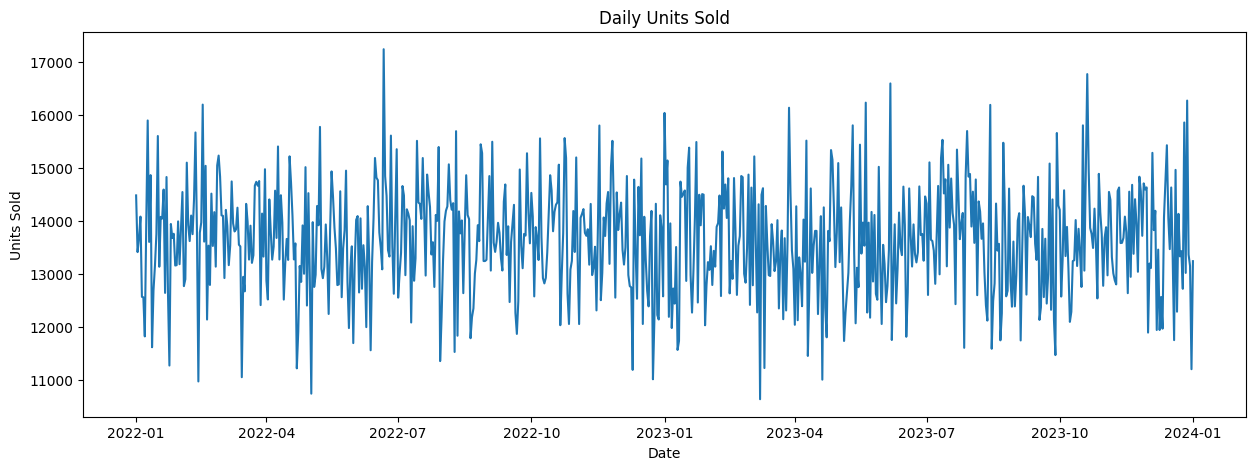

In [25]:
plt.figure(figsize=(15,5))

plt.plot(daily_sales.index,
    daily_sales["Units Sold"])

plt.title("Daily Units Sold")

plt.xlabel("Date")

plt.ylabel("Units Sold")

plt.show()

In [26]:
daily_sales.to_csv(
    "../data/processed/daily_sales.csv")

print("Daily time-series dataset saved.")

Daily time-series dataset saved.


## Observations

Summarize the following after inspecting the plots:

- Overall sales trend
- Fluctuations in demand
- Presence of seasonality (if any)
- Periods of unusually high or low sales

These observations will guide the anomaly detection and forecasting stages.

In [27]:
# Create a complete daily date range

all_dates = pd.date_range(
    start=daily_sales.index.min(),
    end=daily_sales.index.max(),
    freq="D"
)

# Reindex the time series to include missing dates

daily_sales = daily_sales.reindex(all_dates)

daily_sales.index.name = "Date"

print("Missing values before interpolation:")
print(daily_sales["Units Sold"].isnull().sum())

Missing values before interpolation:
0


In [28]:
# Fill missing daily sales values using linear interpolation

daily_sales["Units Sold"] = (
    daily_sales["Units Sold"]
    .interpolate(method="linear")
)

print("Missing values after interpolation:")
print(daily_sales["Units Sold"].isnull().sum())

Missing values after interpolation:
0


In [30]:
daily_sales.head()


,Units Sold
Date,
2023-12-28,16271
2023-12-29,13368
2023-12-30,13156
2023-12-31,11208
2024-01-01,13244


In [31]:
daily_sales.tail()

,Units Sold
Date,
2023-12-28,16271
2023-12-29,13368
2023-12-30,13156
2023-12-31,11208
2024-01-01,13244


In [32]:
from statsmodels.tsa.seasonal import seasonal_decompose

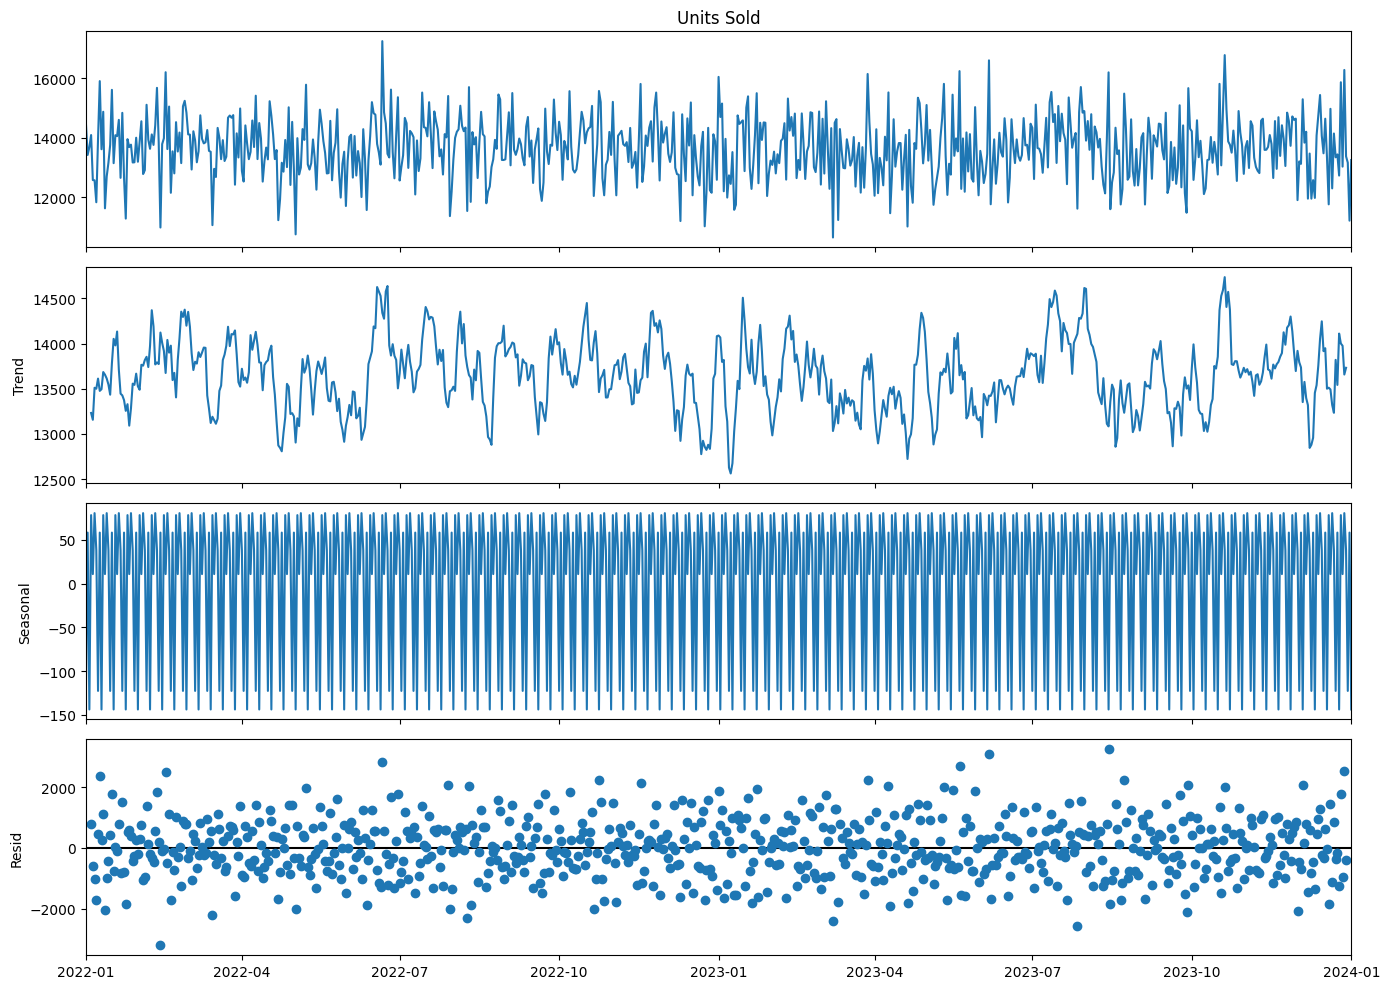

In [33]:
decomposition = seasonal_decompose(
    daily_sales["Units Sold"],
    model="additive",
    period=7
)

fig = decomposition.plot()

fig.set_size_inches(14, 10)

plt.tight_layout()

plt.show()

In [34]:
# Save the final prepared daily time series

daily_sales.to_csv(
    "../data/processed/daily_sales.csv"
)

print("Final daily time-series dataset saved successfully.")

Final daily time-series dataset saved successfully.


## Time-Series Decomposition

The daily sales time series was decomposed into four components: observed sales, trend, seasonality, and residual noise.

The **observed** component represents the original daily sales values.

The **trend** component shows the underlying long-term movement in sales.

The **seasonal** component represents recurring patterns in demand. A period of 7 days was used to examine weekly seasonality in daily retail sales.

The **residual** component represents irregular fluctuations that are not explained by the trend or seasonal components.

This decomposition helps distinguish systematic demand patterns from unexpected variations and provides a foundation for anomaly detection and demand forecasting.